In [2]:
import pandas as pd
import re
import numpy as np
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr
import matplotlib.cm as cm
from matplotlib.colors import to_hex

In [19]:
# Load correlation Data
vaab_tra = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/03vabb_assoc-08052025.csv")

In [20]:
# Define brain-related rows
brain_df = vaab_tra[vaab_tra['Tissue'].str.contains('brain', case=False, na=False)]
# Bonferroni correction based on number of tests in brain only
bonf_threshold = 0.05 / brain_df.shape[0]
print(bonf_threshold)
# Filter significant rows
significant_brain_df = brain_df[brain_df['P-value'] < bonf_threshold]
significant_brain_df

0.0002777777777777778


,Phenotype,Clock,Beta,SE,z-value,P-value,CI_lower_95,CI_upper_95,Converged,Tissue
2126,Alcohol,deMagalhaes_brain_clock,-0.906312,0.244039,-3.713799,0.000204,-1.384619,-0.428004,True,brain
2128,Alcohol,GTExAge_brain_clock,-1.387905,0.342638,-4.050641,0.000051,-2.059463,-0.716346,True,brain
4011,Polysubstance,all_brain_clock,-0.978439,0.266619,-3.669804,0.000243,-1.501002,-0.455876,True,brain


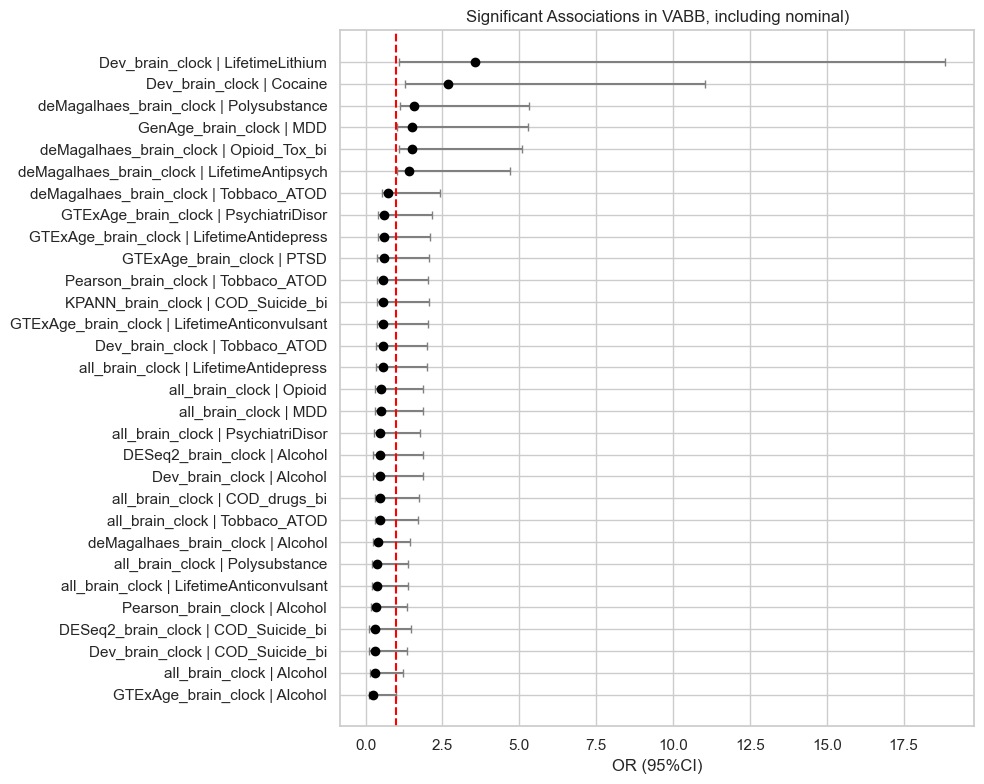

In [25]:
# Load your dataframe
brain_df = brain_df.copy()

# Define brain-related tissues
#brain_tissues = ['brain']

# Filter: significant results & brain tissues
brain_df = brain_df[
    (brain_df['P-value'] < 0.05)
].copy()

# Add OR and 95% CI for OR
brain_df['OR'] = np.exp(brain_df['Beta'])
brain_df['OR_lower'] = np.exp(brain_df['CI_lower_95'])
brain_df['OR_upper'] = np.exp(brain_df['CI_upper_95'])

# Sort by beta for visual clarity
brain_df = brain_df.sort_values('Beta')

# Plot
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")

# Error bars = 95% CI
plt.errorbar(
    x=brain_df['OR'],
    y=brain_df['Clock'] + ' | ' + brain_df['Phenotype'],
    xerr=[brain_df['OR'] - brain_df['OR_lower'],
          brain_df['OR'] + brain_df['OR_upper']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)

plt.axvline(1.0, color='red', linestyle='--')
plt.xlabel('OR (95%CI)')
plt.title('Significant Associations in VABB, including nominal)')
plt.tight_layout()
plt.show()

In [27]:
# Load correlation Data
vaab_tra2 = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/04vabb_assoc-08062025.csv")
vaab_tra2

,Region,Phenotype,Clock,Beta,SE,z-value,P-value,CI_lower_95,CI_upper_95,Converged,Tissue
0,BA25,PsychiatriDisor,GenAge_heart_clock,1.942275,0.555235,3.498112,0.000469,0.854034,3.030515,True,heart
1,BA25,MDD,GenAge_heart_clock,2.222012,0.645112,3.444383,0.000572,0.957616,3.486408,True,heart
2,BA24,LifetimeAntipsych,all_ovary_clock,-1.898922,0.556472,-3.412430,0.000644,-2.989587,-0.808257,True,ovary
3,BA25,COD_drugs_bi,Dev_vagina_clock,2.131650,0.625421,3.408346,0.000654,0.905848,3.357452,True,vagina
4,BA24,MDD,Peters_stomach_clock,3.794967,1.137186,3.337156,0.000846,1.566124,6.023810,True,stomach
...,...,...,...,...,...,...,...,...,...,...,...
16716,BA9,Inhalant,GenAge_vagina_clock,NaN,NaN,NaN,NaN,NaN,NaN,False,vagina
16717,BA9,Inhalant,GTExAge_vagina_clock,NaN,NaN,NaN,NaN,NaN,NaN,False,vagina
16718,BA9,Inhalant,Peters_vagina_clock,NaN,NaN,NaN,NaN,NaN,NaN,False,vagina
16719,BA9,Inhalant,all_vagina_clock,NaN,NaN,NaN,NaN,NaN,NaN,False,vagina


In [29]:
# Filter brain-related tissues only
brain_df = vaab_tra2[vaab_tra2['Tissue'].str.contains('brain', case=False, na=False)].copy()

# Initialize list to collect results
significant_by_region = []

# Loop over each region
for region, group in brain_df.groupby('Region'):
    n_tests = group.shape[0]
    bonf_threshold = 0.05 / n_tests
    sig_rows = group[group['P-value'] < bonf_threshold].copy()
    sig_rows['Bonf_threshold'] = bonf_threshold  # optional: store threshold used
    significant_by_region.append(sig_rows)

# Combine all significant rows
significant_brain_df = pd.concat(significant_by_region, ignore_index=True)

# Show result
significant_brain_df

,Region,Phenotype,Clock,Beta,SE,z-value,P-value,CI_lower_95,CI_upper_95,Converged,Tissue,Bonf_threshold


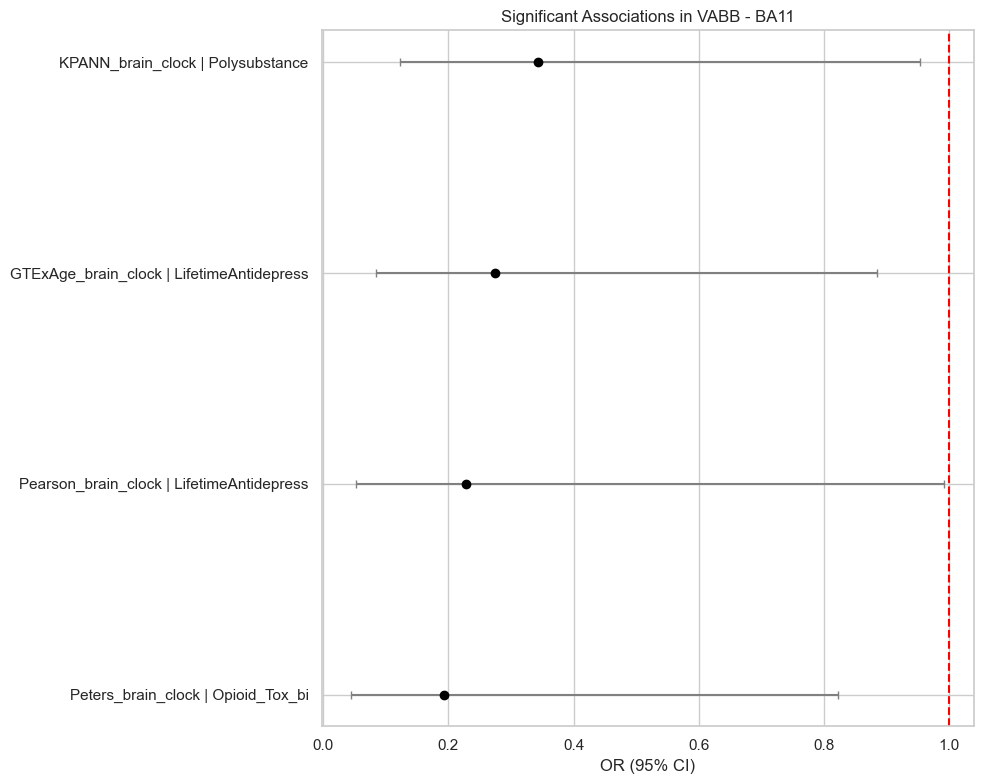

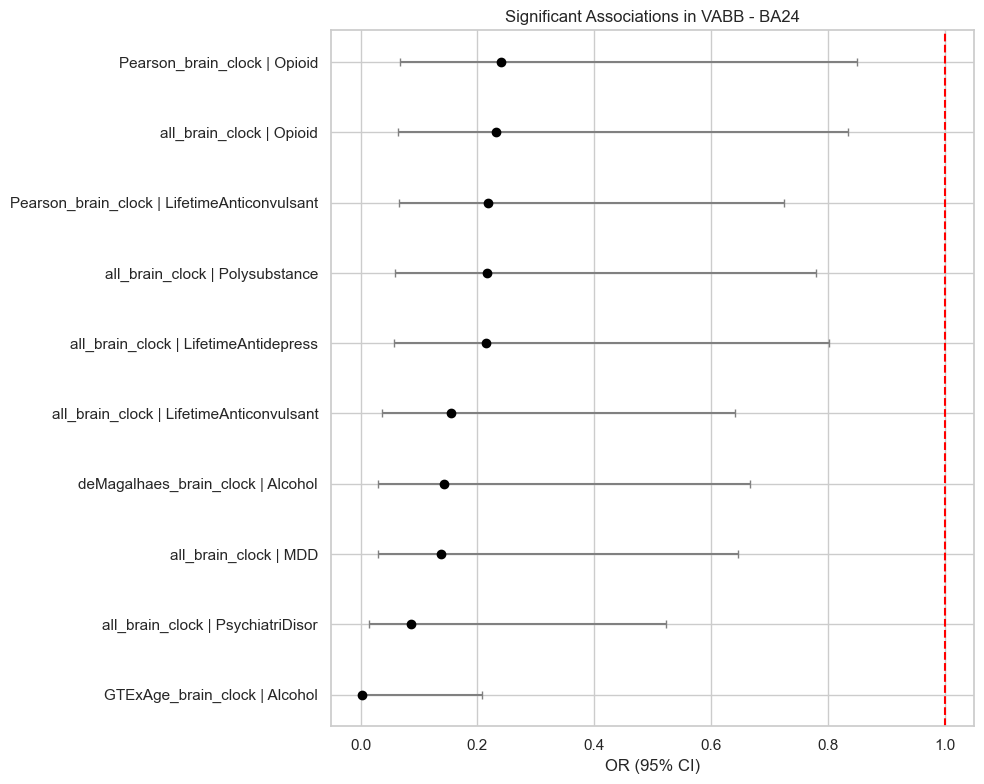

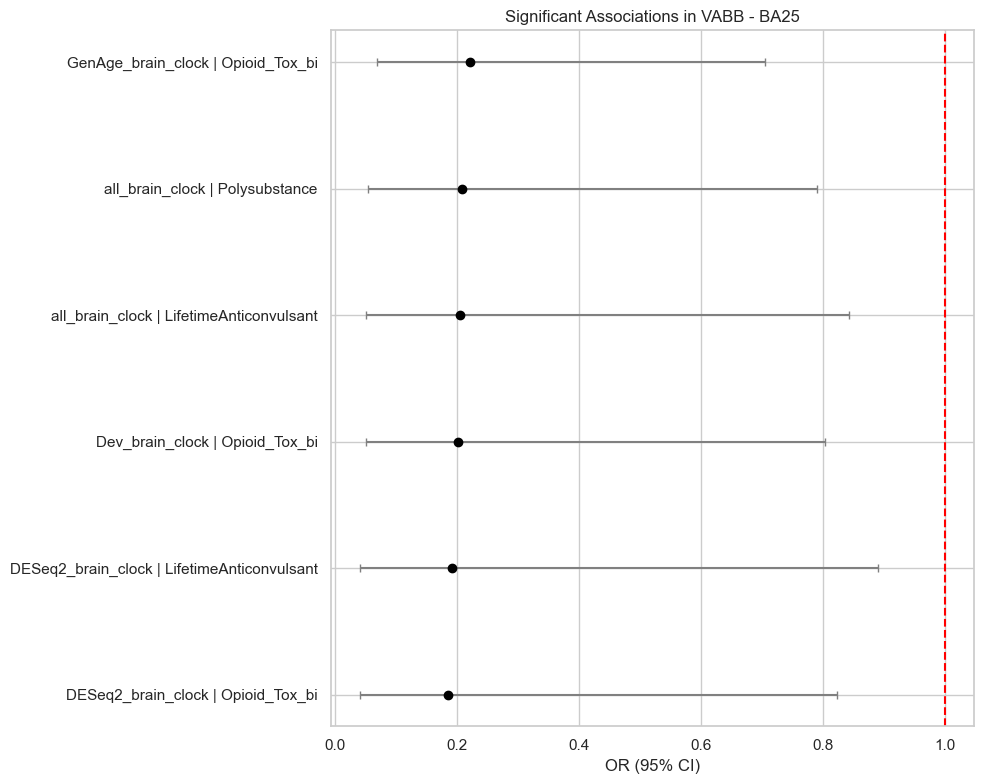

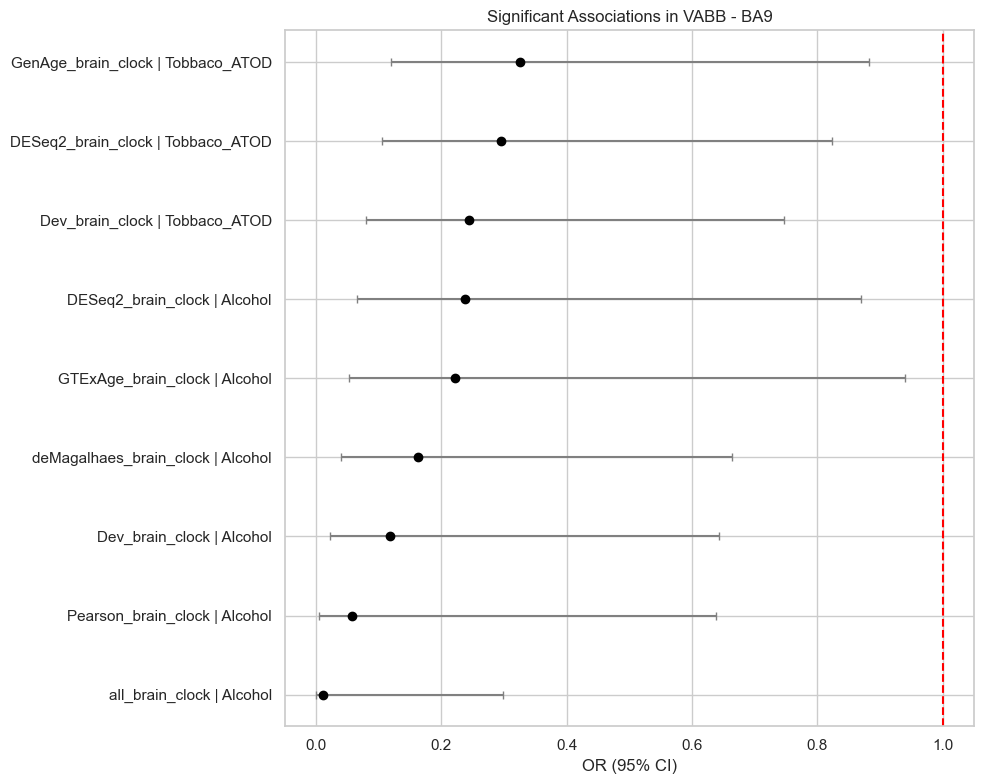

In [30]:
# Filter for significant brain-related results
brain_df = brain_df[brain_df['P-value'] < 0.05].copy()

# Add OR and 95% CI for OR
brain_df['OR'] = np.exp(brain_df['Beta'])
brain_df['OR_lower'] = np.exp(brain_df['CI_lower_95'])
brain_df['OR_upper'] = np.exp(brain_df['CI_upper_95'])

# Loop through each brain region
for region, region_df in brain_df.groupby('Region'):
    
    # Sort by Beta and optionally remove last two rows
    region_df = region_df.sort_values('Beta').iloc[:-2].copy()

    # Prepare y-labels
    y_labels = region_df['Clock'] + ' | ' + region_df['Phenotype']

    # Plot
    plt.figure(figsize=(10, 8))
    sns.set(style="whitegrid")

    # Error bars = 95% CI
    plt.errorbar(
        x=region_df['OR'],
        y=y_labels,
        xerr=[region_df['OR'] - region_df['OR_lower'],
              region_df['OR_upper'] - region_df['OR']],
        fmt='o',
        color='black',
        ecolor='gray',
        capsize=3
    )

    plt.axvline(1.0, color='red', linestyle='--')
    plt.xlabel('OR (95% CI)')
    plt.title(f'Significant Associations in VABB - {region}')
    plt.tight_layout()
    plt.show()